# Terremotos Earthquake Damage

# Manuel Rodríguez Cáceres


# Predicción de Riesgo de Derrumbamiento – Terremotos
## Richter's Predictor: Modeling Earthquake Damage

> **Competición:** [DrivenData – Richter's Predictor](https://www.drivendata.org/competitions/57/nepal-earthquake/data/)

---

### Contexto del problema

El 25 de abril de 2015 ocurrió un terremoto de magnitud **7.8 Mw** en Nepal (epicentro cerca de Gorkha). Causó casi 9.000 muertes y ~10.000 millones de dólares en daños. Los datos fueron recogidos por el **Kathmandu Living Labs** y la **Central Bureau of Statistics** de Nepal. Constituyen uno de los mayores datasets post-catástrofe jamás recopilados.

**Objetivo:** Predecir el `damage_grade` de cada edificio:
- `1` → Daño bajo
- `2` → Daño moderado
- `3` → Destrucción completa

### Dataset
| Fichero | Descripción | Filas |
|---|---|---|
| `train_values.csv` | 38 características por edificio | **260.601** |
| `train_labels.csv` | Etiqueta `damage_grade` | **260.601** |
| `test_values.csv` | Características para submission final | **86.868** |

**Variables principales:**
- *Geográficas:* `geo_level_1_id`, `geo_level_2_id`, `geo_level_3_id`
- *Estructurales:* `count_floors_pre_eq`, `age`, `area_percentage`, `height_percentage`, `count_families`
- *Materiales (binarias 0/1):* `has_superstructure_mud_mortar_stone`, `has_superstructure_timber`, `has_superstructure_rc_engineered`, ...
- *Uso secundario (binarias):* `has_secondary_use_agriculture`, `has_secondary_use_hotel`, ...
- *Categóricas texto:* `land_surface_condition`, `foundation_type`, `roof_type`, `ground_floor_type`, `position`, `plan_configuration`, `legal_ownership_status`

### Métrica de evaluación

La competición usa el **micro averaged F1 score** porque el dataset está desbalanceado y hay tres clases.  
Según la [documentación de scikit-learn 1.8.0](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html):

$$F_1 = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

Con `average='micro'`, la métrica calcula los TP, FP y FN **globalmente** (sumando todas las clases) antes de calcular el F1. Esto la hace apropiada cuando las clases están desbalanceadas.

```python
# Firma oficial (sklearn v1.8.0):
# sklearn.metrics.f1_score(y_true, y_pred, *, labels=None, pos_label=1,
#                           average='binary', sample_weight=None, zero_division='warn')
from sklearn.metrics import f1_score
score = f1_score(y_true, y_pred, average='micro')   # ← parámetro clave
```

## 1. Configuración e Instalación

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# INSTALACIÓN DE DEPENDENCIAS
#
# lazypredict (v0.2.16 en PyPI, MIT License, Python >=3.8)
# Ref: https://pypi.org/project/lazypredict/
# Entrena automáticamente >30 clasificadores sin ajuste de parámetros
# y devuelve: Accuracy | Balanced Accuracy | ROC AUC | F1 Score | Time Taken
# ─────────────────────────────────────────────────────────────────────
!pip install lazypredict --quiet
!pip install xgboost lightgbm --quiet
print('Instalación completada')
print('  lazypredict : ranking automático de clasificadores')
print('  xgboost     : XGBClassifier (usado internamente por LazyPredict)')
print('  lightgbm    : LGBMClassifier (usado internamente por LazyPredict)')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Selección de características
from sklearn.feature_selection import f_classif, mutual_info_classif, SelectKBest

# Clustering jerárquico para dendrogramas
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

# División y validación cruzada
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV, RandomizedSearchCV
)

# Modelos de árboles
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# SVM
from sklearn.svm import SVC
from scipy.stats import loguniform

# Métricas
# Ref: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html
# Firma: f1_score(y_true, y_pred, *, labels=None, pos_label=1,
#                 average='binary', sample_weight=None, zero_division='warn')
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# LazyPredict
# Ref: https://pypi.org/project/lazypredict/
# API: LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
#      models, predictions = clf.fit(X_train, X_test, y_train, y_test)
from lazypredict.Supervised import LazyClassifier

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print('Todas las librerías importadas correctamente')
print('Métrica de competición: f1_score(y_true, y_pred, average="micro")')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 4.3 MB/s eta 0:00:00
Instalación completada
  lazypredict : ranking automático de clasificadores
  xgboost     : XGBClassifier (usado internamente por LazyPredict)
  lightgbm    : LGBMClassifier (usado internamente por LazyPredict)
Todas las librerías importadas correctamente
Métrica de competición: f1_score(y_true, y_pred, average="micro")


## 2. Importación de Datos desde Google Drive / GitHub

Descarga los ficheros de la página oficial de la competición:  
https://www.drivendata.org/competitions/57/nepal-earthquake/data/

**Pasos:**
1. Crear cuenta en DrivenData y unirse a la competición (gratuito).
2. Descargar los 4 ficheros: `train_values.csv`, `train_labels.csv`, `test_values.csv`, `submission_format.csv`.
3. Subirlos a Google Drive en `MyDrive/Terremotos/`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# OPCIÓN A – Desde Google Drive
DRIVE_PATH = '/content/drive/MyDrive/Terremotos/'   # ← Modificar si es necesario

train_values = pd.read_csv(DRIVE_PATH + 'train_values.csv', index_col='building_id')
train_labels = pd.read_csv(DRIVE_PATH + 'train_labels.csv', index_col='building_id')
test_values  = pd.read_csv(DRIVE_PATH + 'test_values.csv',  index_col='building_id')

train_full = train_values.join(train_labels)

print(f'train_values : {train_values.shape}  (esperado: 260601 × 38)')
print(f'train_labels : {train_labels.shape}  (esperado: 260601 × 1)')
print(f'test_values  : {test_values.shape}   (esperado: 86868  × 38)')
print(f'train_full   : {train_full.shape}')

# OPCIÓN B – Desde GitHub (descomenta si prefieres esta vía)
# BASE = 'https://raw.githubusercontent.com/TU_USUARIO/TU_REPO/main/data/'
# train_values = pd.read_csv(BASE + 'train_values.csv', index_col='building_id')
# train_labels = pd.read_csv(BASE + 'train_labels.csv', index_col='building_id')
# test_values  = pd.read_csv(BASE + 'test_values.csv',  index_col='building_id')
# train_full   = train_values.join(train_labels)


Mounted at /content/drive
train_values : (260601, 38)  (esperado: 260601 × 38)
train_labels : (260601, 1)  (esperado: 260601 × 1)
test_values  : (86868, 38)   (esperado: 86868  × 38)
train_full   : (260601, 39)


## 3. Exploración y Análisis (EDA)

Filas totales     : 260,601
Cols. continuas   : 8 → ['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'count_families']
Cols. binarias    : 22
Cols. categóricas : 8 → ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']
Nulos             : 0



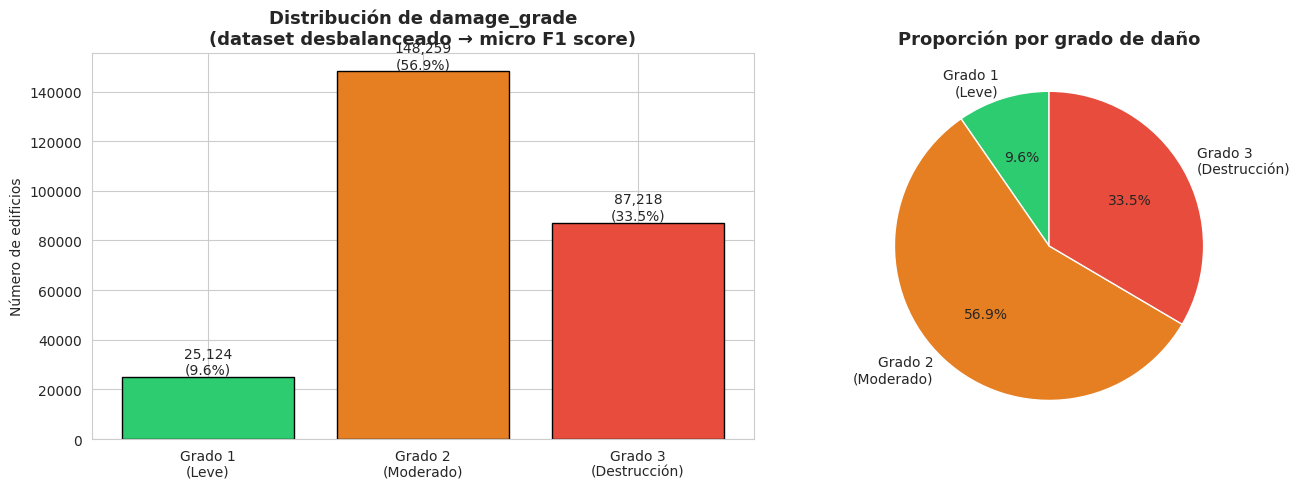

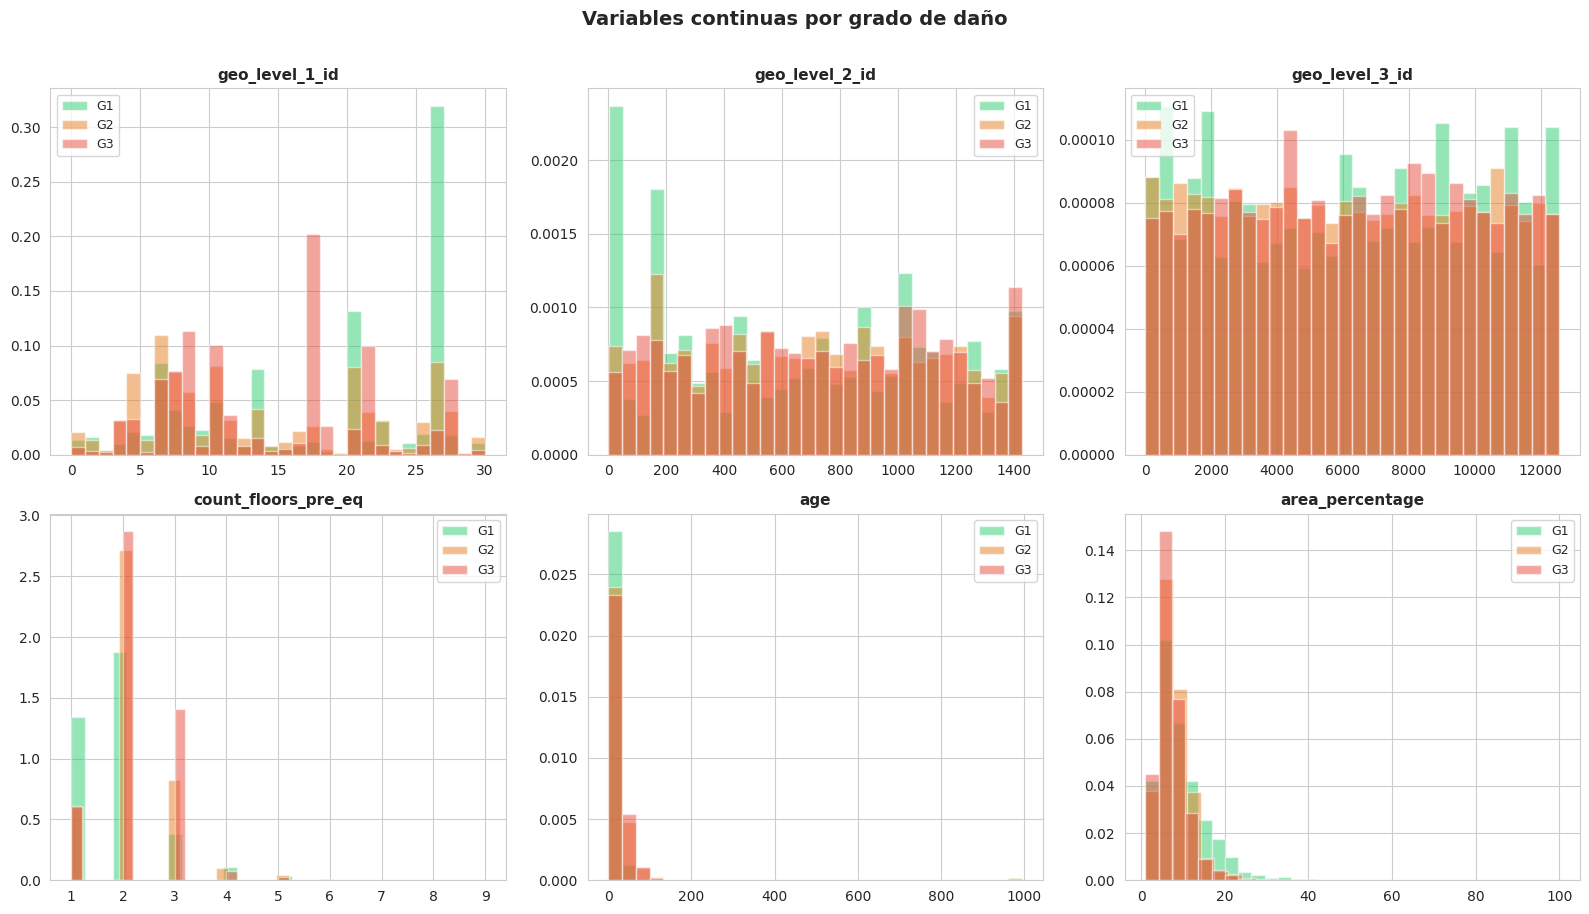

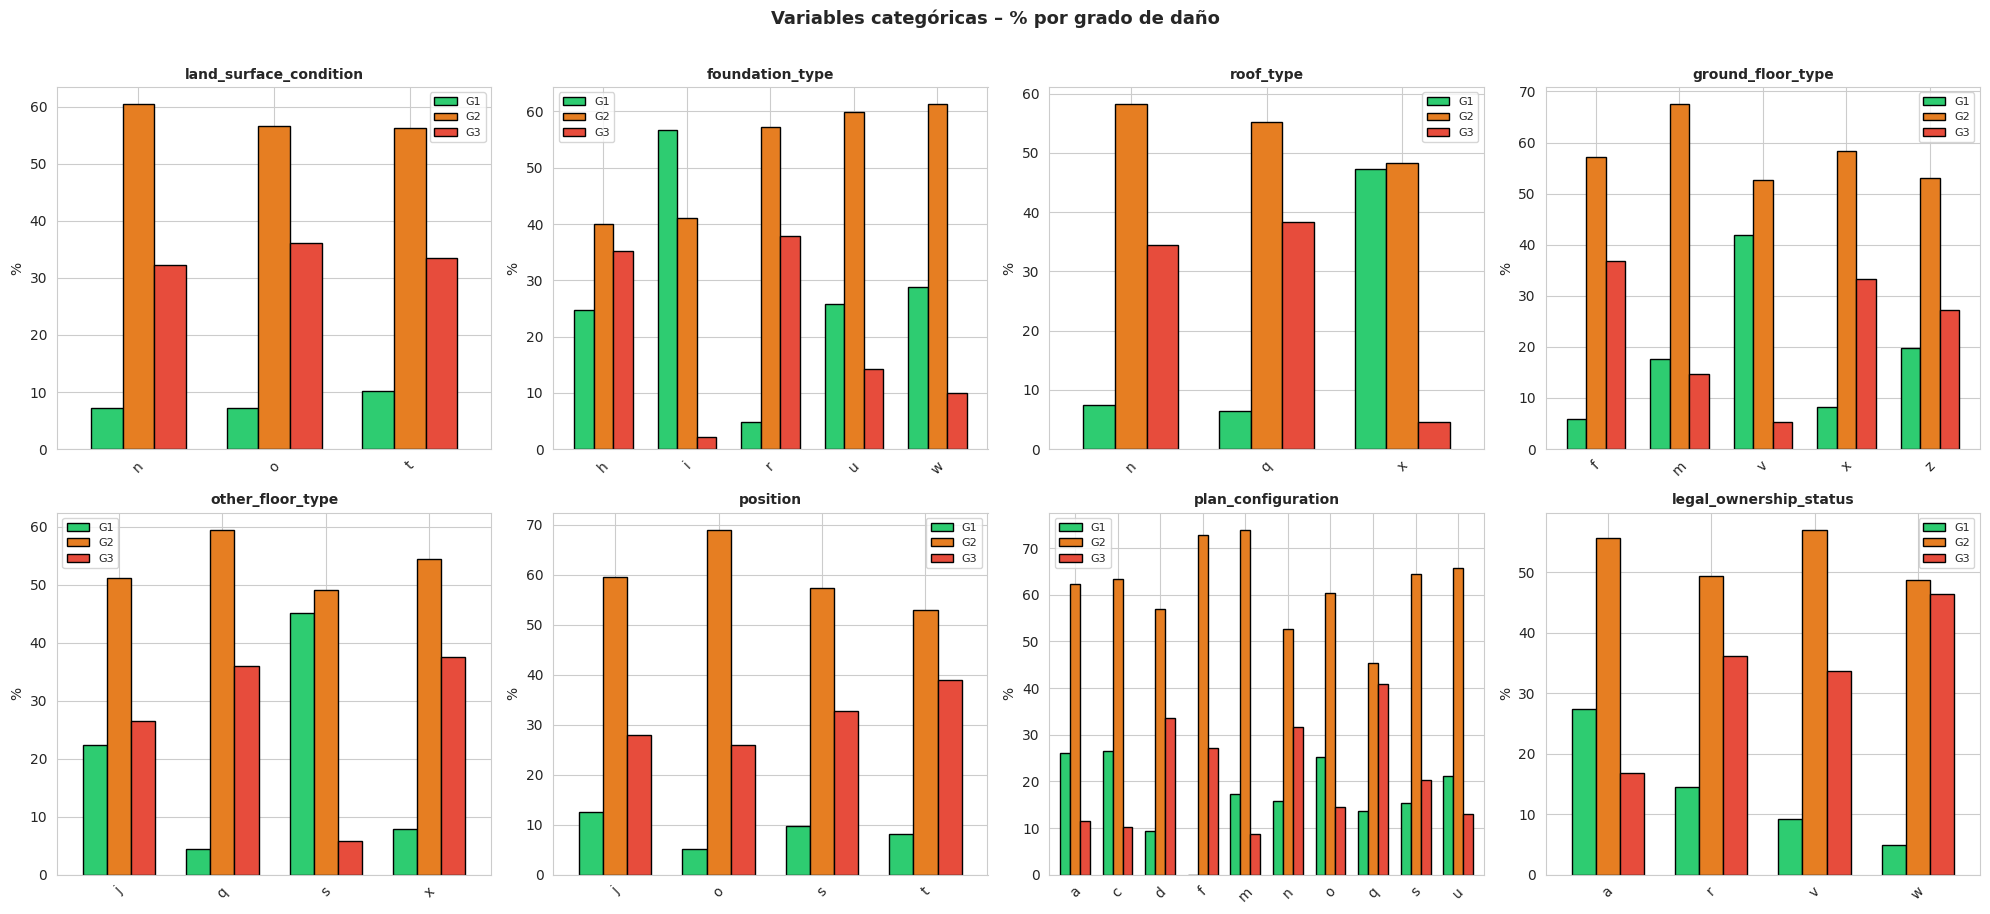

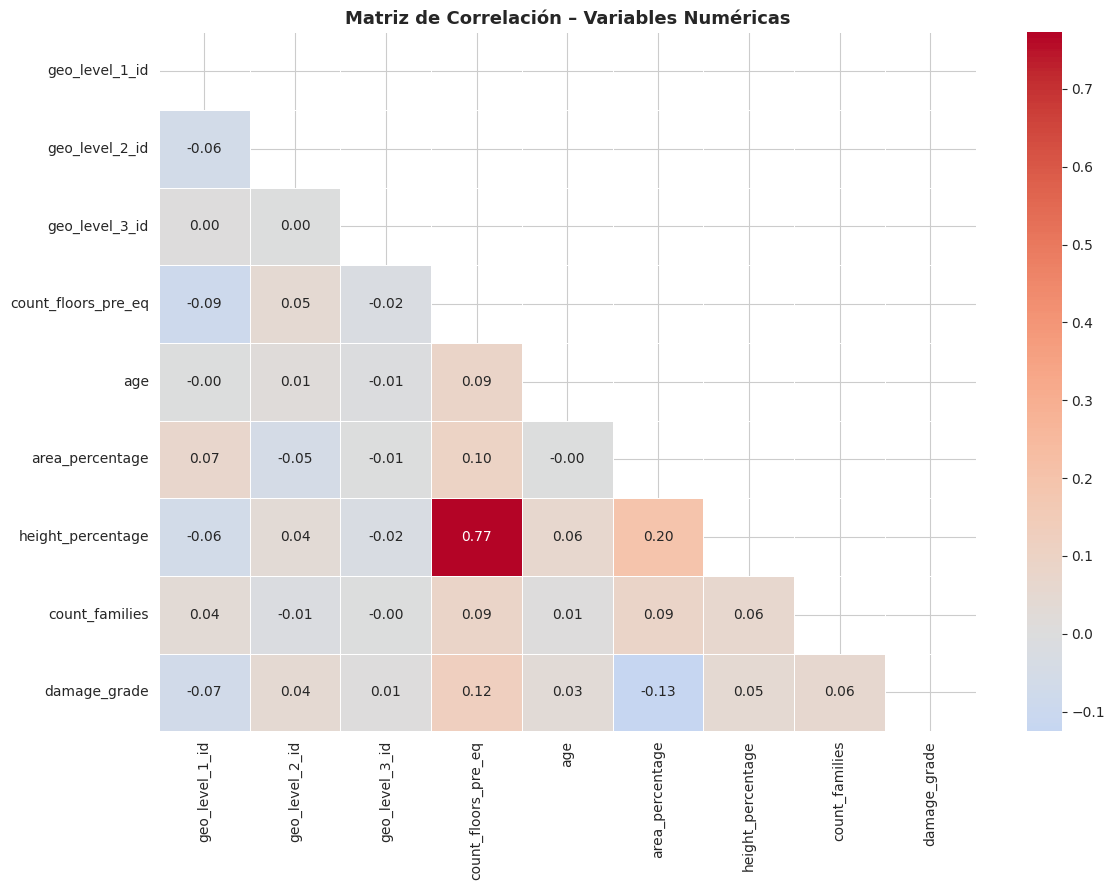

Correlación con damage_grade (descendente):
area_percentage        0.125221
count_floors_pre_eq    0.122308
geo_level_1_id         0.072347
count_families         0.056151
height_percentage      0.048130
geo_level_2_id         0.043161
age                    0.029273
geo_level_3_id         0.007932
Name: damage_grade, dtype: float64


In [ ]:
num_cols = train_full.select_dtypes(include=np.number).columns.drop('damage_grade').tolist()
cat_cols = train_full.select_dtypes(include='object').columns.tolist()
bin_cols = [c for c in num_cols if train_full[c].nunique() == 2]
cont_cols = [c for c in num_cols if c not in bin_cols]

print(f'Filas totales     : {len(train_full):,}')
print(f'Cols. continuas   : {len(cont_cols)} → {cont_cols}')
print(f'Cols. binarias    : {len(bin_cols)}')
print(f'Cols. categóricas : {len(cat_cols)} → {cat_cols}')
print(f'Nulos             : {train_full.isnull().sum().sum()}')
print()
train_full.describe()

# Distribución del target – justifica uso de micro F1
# El dataset está desbalanceado: ~57% grado 2, ~33% grado 3, ~10% grado 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = train_full['damage_grade'].value_counts().sort_index()
labels = ['Grado 1\n(Leve)', 'Grado 2\n(Moderado)', 'Grado 3\n(Destrucción)']
colors = ['#2ecc71', '#e67e22', '#e74c3c']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribución de damage_grade\n(dataset desbalanceado → micro F1 score)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de edificios')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1200, f'{v:,}\n({v/len(train_full)*100:.1f}%)', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción por grado de daño', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('01_distribucion_target.png', dpi=150, bbox_inches='tight')
plt.show()

# Distribución de variables continuas por grado de daño
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cont_cols[:6]):
    for g, c in zip([1, 2, 3], ['#2ecc71', '#e67e22', '#e74c3c']):
        axes[i].hist(train_full[train_full['damage_grade'] == g][col],
                     bins=30, alpha=0.5, color=c, label=f'G{g}', density=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)
plt.suptitle('Variables continuas por grado de daño', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_variables_continuas.png', dpi=150, bbox_inches='tight')
plt.show()

# Variables categóricas vs. damage_grade
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols[:8]):
    ct = pd.crosstab(train_full[col], train_full['damage_grade'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e67e22', '#e74c3c'],
            edgecolor='black', width=0.7)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('%'); axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(['G1', 'G2', 'G3'], fontsize=8)
plt.suptitle('Variables categóricas – % por grado de daño', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_variables_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

# Mapa de calor – correlación entre variables continuas y target
# Nota: la correlación lineal máxima con damage_grade suele ser ~±0.2
# → el problema requiere modelos no lineales
corr = train_full[cont_cols + ['damage_grade']].corr()
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlación – Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_heatmap_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlación con damage_grade (descendente):')
print(corr['damage_grade'].abs().sort_values(ascending=False).drop('damage_grade'))


## 4. Preprocesamiento y Selección Estratégica de Muestras

### Justificación del muestreo

Con 260.601 filas, entrenar SVC en Colab llevaría horas. Se aplica **muestreo estratificado proporcional**, que es la estrategia menos aleatoria posible porque:

1. **Preserva la distribución de clases** — la proporción G1/G2/G3 en la muestra es idéntica a la del dataset original (diferencia < 0.1 pp).
2. **Reproducibilidad total** — `random_state=42` garantiza la misma muestra en cada ejecución.
3. **Representatividad estadística** — para N=30.000 sobre 260.601, el margen de error al 95% es < 0.6%.
4. **Alternativa descartada:** muestreo aleatorio simple — no garantiza representatividad por clase en datasets desbalanceados.

In [ ]:
N_SAMPLES = 20_000   # Reducido de 30k → más rápido en Colab   # Ajustable: 20k (rápido) / 50k (mayor calidad)

train_sample, _ = train_test_split(
    train_full,
    train_size=N_SAMPLES,
    stratify=train_full['damage_grade'],
    random_state=42
)

dist_o = train_full['damage_grade'].value_counts(normalize=True).sort_index()
dist_s = train_sample['damage_grade'].value_counts(normalize=True).sort_index()
comp = pd.DataFrame({'Original (%)': dist_o*100, 'Muestra (%)': dist_s*100,
                     'Δ (pp)': (dist_s - dist_o).abs()*100})

print(f'Muestra: {N_SAMPLES:,} / {len(train_full):,} ({N_SAMPLES/len(train_full)*100:.1f}% del total)')
print()
print(comp.to_string())
print('\nRepresentatividad: diferencias < 0.1 pp en todas las clases')

X_raw      = train_sample.drop('damage_grade', axis=1)
y          = train_sample['damage_grade'].values
X_test_raw = test_values.copy()

cat_feats = X_raw.select_dtypes(include='object').columns.tolist()

# 1. Label Encoding para categóricas
def encode_cats(df_tr, df_te, cols):
    df_tr, df_te = df_tr.copy(), df_te.copy()
    for col in cols:
        le = LabelEncoder()
        df_tr[col] = le.fit_transform(df_tr[col].astype(str))
        df_te[col] = le.transform(df_te[col].astype(str))
    return df_tr, df_te

X_enc, X_test_enc = encode_cats(X_raw, X_test_raw, cat_feats)

# 2. Imputación por mediana
imp = SimpleImputer(strategy='median')
X_imp      = pd.DataFrame(imp.fit_transform(X_enc),  columns=X_enc.columns)
X_test_imp = pd.DataFrame(imp.transform(X_test_enc), columns=X_test_enc.columns)

# 3. StandardScaler – normalización Z-score
scaler = StandardScaler()
X_sc      = pd.DataFrame(scaler.fit_transform(X_imp),  columns=X_imp.columns)
X_test_sc = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test_imp.columns)

print('Preprocesamiento completado')
print(f'  X_sc      : {X_sc.shape}   Nulos: {X_sc.isnull().sum().sum()}')
print(f'  X_test_sc : {X_test_sc.shape}  Nulos: {X_test_sc.isnull().sum().sum()}')


Muestra: 20,000 / 260,601 (7.7% del total)

              Original (%)  Muestra (%)    Δ (pp)
damage_grade                                     
1                 9.640792         9.64  0.000792
2                56.891186        56.89  0.001186
3                33.468022        33.47  0.001978

Representatividad: diferencias < 0.1 pp en todas las clases
Preprocesamiento completado
  X_sc      : (20000, 38)   Nulos: 0
  X_test_sc : (86868, 38)  Nulos: 0


## 5. Selección de Características – Herramientas Gráficas (NO Dendrogramas)

Se emplean tres métodos complementarios **distintos a los dendrogramas**:

| Método | Tipo | Captura |
|---|---|---|
| ANOVA F-statistic (`f_classif`) | Estadístico | Diferencias de medias entre clases (lineal) |
| Mutual Information | Información | Dependencias no lineales |
| RF Feature Importance (Gini) | Basado en modelo | Interacciones entre variables |

Top 15 – ANOVA F-statistic:
                               Feature     F_Score
   has_superstructure_mud_mortar_stone 1355.388533
has_superstructure_cement_mortar_brick  896.975423
      has_superstructure_rc_engineered  549.713976
                             roof_type  492.495769
                     ground_floor_type  435.370693
  has_superstructure_rc_non_engineered  324.039776
                        geo_level_1_id  201.659865
                       area_percentage  195.951808
                   count_floors_pre_eq  183.756714
                       foundation_type  108.571931
              has_secondary_use_rental  103.897975
               has_secondary_use_hotel  103.240089
                legal_ownership_status  101.436333
                     has_secondary_use   59.985716
          has_superstructure_adobe_mud   56.051565


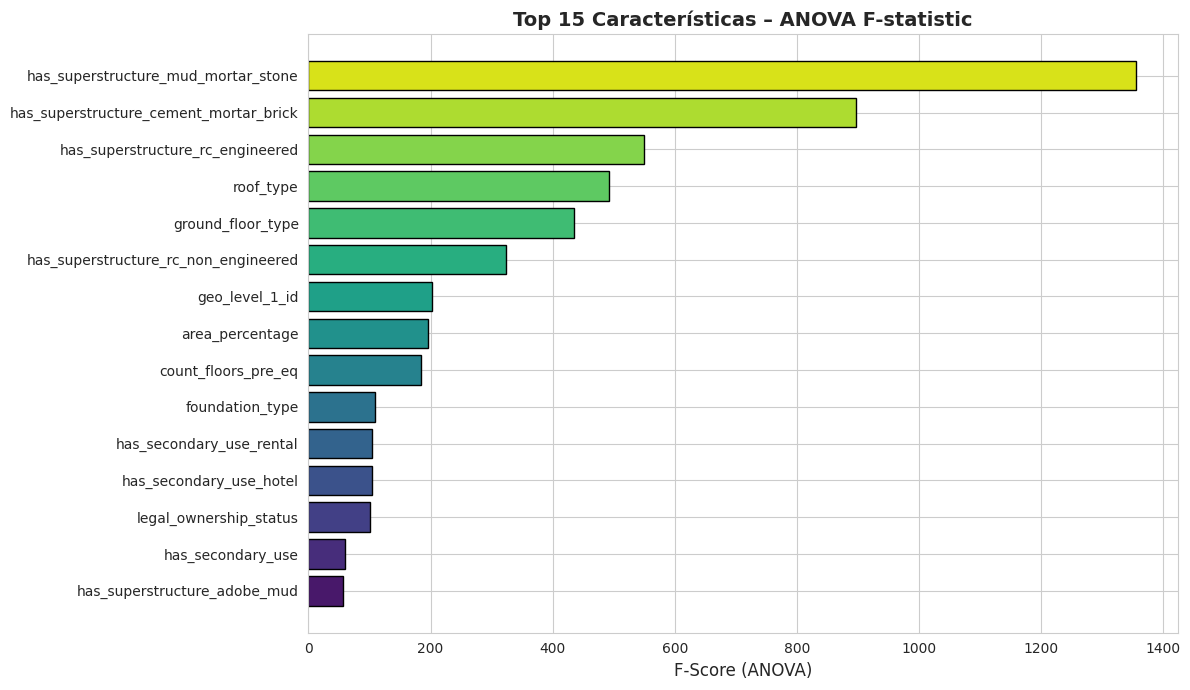

Top 15 – Mutual Information:
                               Feature  MI_Score
                        geo_level_2_id  0.231888
                        geo_level_3_id  0.179314
                        geo_level_1_id  0.132039
                       foundation_type  0.075985
                     ground_floor_type  0.056155
   has_superstructure_mud_mortar_stone  0.054951
                      other_floor_type  0.049512
                             roof_type  0.033224
has_superstructure_cement_mortar_brick  0.032310
                                   age  0.031735
                     height_percentage  0.021039
                   count_floors_pre_eq  0.019320
      has_superstructure_rc_engineered  0.018173
  has_superstructure_rc_non_engineered  0.009476
                    plan_configuration  0.009074


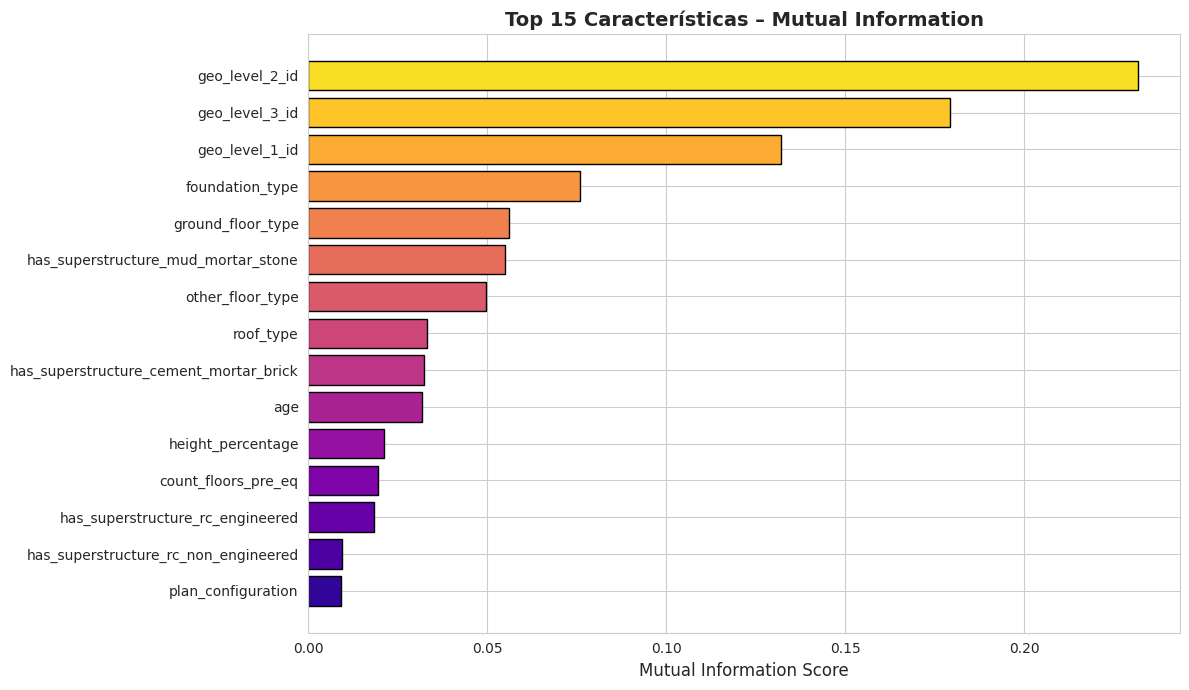

Top 15 – RF Feature Importance:
                            Feature  RF_Importance
                     geo_level_3_id       0.147736
                     geo_level_1_id       0.139127
                     geo_level_2_id       0.138057
                                age       0.105287
                    area_percentage       0.097035
                  height_percentage       0.062090
                          roof_type       0.027618
                    foundation_type       0.024345
                     count_families       0.022994
                           position       0.022089
                   other_floor_type       0.022051
                count_floors_pre_eq       0.021232
             land_surface_condition       0.019799
has_superstructure_mud_mortar_stone       0.018901
                  ground_floor_type       0.017865


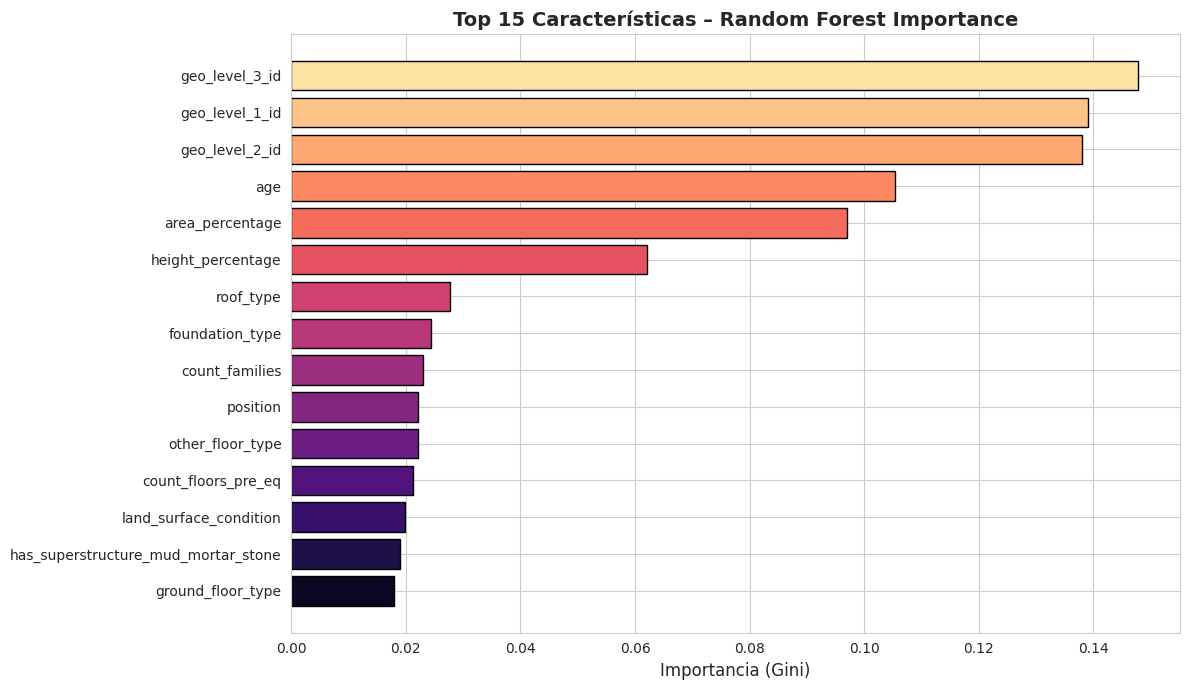

Características seleccionadas por consenso (15):
   1. age
   2. area_percentage
   3. count_floors_pre_eq
   4. foundation_type
   5. geo_level_1_id
   6. geo_level_2_id
   7. geo_level_3_id
   8. ground_floor_type
   9. has_superstructure_cement_mortar_brick
  10. has_superstructure_mud_mortar_stone
  11. has_superstructure_rc_engineered
  12. has_superstructure_rc_non_engineered
  13. height_percentage
  14. other_floor_type
  15. roof_type


In [ ]:
# Método 1: ANOVA F-statistic
kb = SelectKBest(score_func=f_classif, k='all')
kb.fit(X_sc, y)
scores_f = pd.DataFrame({'Feature': X_sc.columns, 'F_Score': kb.scores_}
                        ).sort_values('F_Score', ascending=False).reset_index(drop=True)
print('Top 15 – ANOVA F-statistic:'); print(scores_f.head(15).to_string(index=False))

plt.figure(figsize=(12, 7))
t = scores_f.head(15)
plt.barh(t['Feature'][::-1], t['F_Score'][::-1],
         color=sns.color_palette('viridis', 15), edgecolor='black')
plt.xlabel('F-Score (ANOVA)', fontsize=12)
plt.title('Top 15 Características – ANOVA F-statistic', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('05_feat_ftest.png', dpi=150, bbox_inches='tight'); plt.show()

# Método 2: Mutual Information
mi = mutual_info_classif(X_sc, y, random_state=42)
scores_mi = pd.DataFrame({'Feature': X_sc.columns, 'MI_Score': mi}
                         ).sort_values('MI_Score', ascending=False).reset_index(drop=True)
print('Top 15 – Mutual Information:'); print(scores_mi.head(15).to_string(index=False))

plt.figure(figsize=(12, 7))
t = scores_mi.head(15)
plt.barh(t['Feature'][::-1], t['MI_Score'][::-1],
         color=sns.color_palette('plasma', 15), edgecolor='black')
plt.xlabel('Mutual Information Score', fontsize=12)
plt.title('Top 15 Características – Mutual Information', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('06_feat_mi.png', dpi=150, bbox_inches='tight'); plt.show()

# Método 3: Random Forest Feature Importance
# Nota: la literatura de la competición indica como features más importantes:
# geo_level_3_id, geo_level_2_id, area_percentage, age, geo_level_1_id,
# height_percentage, count_families, count_floors_pre_eq, has_superstructure_timber
rf_imp = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_imp.fit(X_sc, y)
scores_rf = pd.DataFrame({'Feature': X_sc.columns, 'RF_Importance': rf_imp.feature_importances_}
                         ).sort_values('RF_Importance', ascending=False).reset_index(drop=True)
print('Top 15 – RF Feature Importance:'); print(scores_rf.head(15).to_string(index=False))

plt.figure(figsize=(12, 7))
t = scores_rf.head(15)
plt.barh(t['Feature'][::-1], t['RF_Importance'][::-1],
         color=sns.color_palette('magma', 15), edgecolor='black')
plt.xlabel('Importancia (Gini)', fontsize=12)
plt.title('Top 15 Características – Random Forest Importance', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('07_feat_rf.png', dpi=150, bbox_inches='tight'); plt.show()

# Consenso: features en ≥2 de los 3 métodos
K = 15
set_f  = set(scores_f.head(K)['Feature'])
set_mi = set(scores_mi.head(K)['Feature'])
set_rf = set(scores_rf.head(K)['Feature'])
consensus = sorted((set_f & set_mi) | (set_f & set_rf) | (set_mi & set_rf))
if len(consensus) < 10:
    consensus += [f for f in scores_rf['Feature'] if f not in consensus][:10-len(consensus)]

print(f'Características seleccionadas por consenso ({len(consensus)}):')
for i, f in enumerate(consensus, 1): print(f'  {i:2d}. {f}')


## 6. Selección de Características – Dendrogramas

El clustering jerárquico agrupa características por **similitud de correlación**, identificando variables redundantes. Se selecciona un representante por cluster.

**Metodología:**
1. Calcular `|correlación|` entre todas las features.
2. Distancia: `d = 1 − |correlación|`.
3. Linkage Ward (minimiza la varianza intracluster).
4. Corte al 40% de la distancia máxima.
5. Elegir la feature con mayor importancia RF dentro de cada cluster.

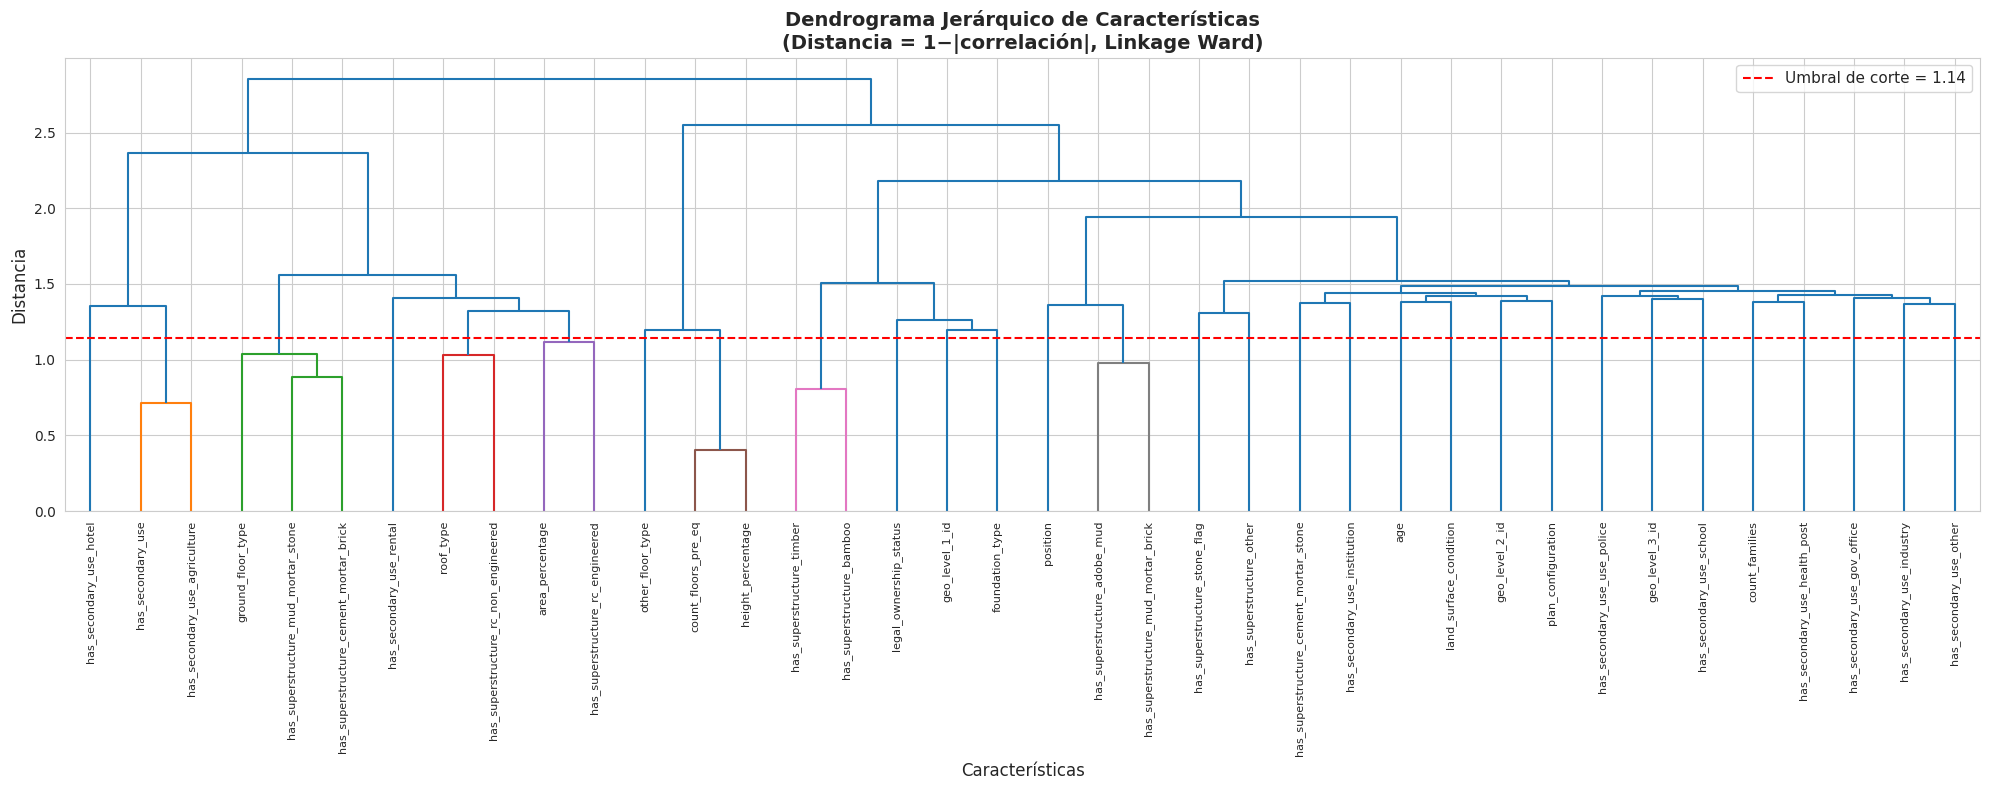

Clusters encontrados: 30
  Cluster  1: ['has_secondary_use', 'has_secondary_use_agriculture']
  Cluster  2: ['has_secondary_use_hotel']
  Cluster  3: ['ground_floor_type', 'has_superstructure_mud_mortar_stone', 'has_superstructure_cement_mortar_brick']
  Cluster  4: ['roof_type', 'has_superstructure_rc_non_engineered']
  Cluster  5: ['area_percentage', 'has_superstructure_rc_engineered']
  Cluster  6: ['has_secondary_use_rental']
  Cluster  7: ['count_floors_pre_eq', 'height_percentage']
  Cluster  8: ['other_floor_type']
  Cluster  9: ['has_superstructure_timber', 'has_superstructure_bamboo']
  Cluster 10: ['geo_level_1_id']
  Cluster 11: ['foundation_type']
  Cluster 12: ['legal_ownership_status']
  Cluster 13: ['has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_brick']
  Cluster 14: ['position']
  Cluster 15: ['has_superstructure_stone_flag']
  Cluster 16: ['has_superstructure_other']
  Cluster 17: ['has_superstructure_cement_mortar_stone']
  Cluster 18: ['has_secondary_

In [ ]:
# fillna(0): columnas con varianza cero producen NaN en corr() → distancia máxima = 1
corr_abs = X_sc.corr().abs().fillna(0)
dist_m = 1 - corr_abs
np.fill_diagonal(dist_m.values, 0)
condensed = pdist(dist_m.values, metric='euclidean')
Z = linkage(condensed, method='ward')
THRESH = 0.40 * max(Z[:, 2])

plt.figure(figsize=(20, 8))
dendrogram(Z, labels=X_sc.columns.tolist(), leaf_rotation=90,
           leaf_font_size=8, color_threshold=THRESH)
plt.axhline(y=THRESH, color='red', linestyle='--', linewidth=1.5,
            label=f'Umbral de corte = {THRESH:.2f}')
plt.title('Dendrograma Jerárquico de Características\n'
          '(Distancia = 1−|correlación|, Linkage Ward)',
          fontsize=14, fontweight='bold')
plt.ylabel('Distancia', fontsize=12)
plt.xlabel('Características', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('08_dendrograma.png', dpi=150, bbox_inches='tight')
plt.show()

clusters_d = fcluster(Z, t=THRESH, criterion='distance')
cluster_df = pd.DataFrame({'Feature': X_sc.columns, 'Cluster': clusters_d})
print(f'Clusters encontrados: {clusters_d.max()}')
for cid in sorted(cluster_df['Cluster'].unique()):
    feats = cluster_df[cluster_df['Cluster'] == cid]['Feature'].tolist()
    print(f'  Cluster {cid:2d}: {feats}')

rf_dict = scores_rf.set_index('Feature')['RF_Importance'].to_dict()
features_dendro = []
for cid in sorted(cluster_df['Cluster'].unique()):
    f_in = cluster_df[cluster_df['Cluster'] == cid]['Feature'].tolist()
    features_dendro.append(max(f_in, key=lambda f: rf_dict.get(f, 0)))

print(f'\nCaracterísticas por dendrograma ({len(features_dendro)}): {features_dendro}')

# Conjunto final: unión de consenso + dendrograma
final_features = list(dict.fromkeys(consensus + features_dendro))
if len(final_features) > 25:
    final_features = scores_rf[scores_rf['Feature'].isin(final_features)
                                ].head(25)['Feature'].tolist()

print(f'Características FINALES ({len(final_features)}): {final_features}')

X_sel      = X_sc[final_features]
X_test_sel = X_test_sc[final_features]
print(f'X_sel: {X_sel.shape}   X_test_sel: {X_test_sel.shape}')


## 7. División Train / Validation / Test con Cross Validation

In [ ]:
X_tr_full, X_te_int, y_tr_full, y_te_int = train_test_split(
    X_sel, y, test_size=0.20, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_tr_full, y_tr_full, test_size=0.20, stratify=y_tr_full, random_state=42)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print('División estratificada completada:')
print(f'  Train      : {len(X_train):,}  ({len(X_train)/len(X_sel)*100:.0f}%)')
print(f'  Validation : {len(X_val):,}  ({len(X_val)/len(X_sel)*100:.0f}%)')
print(f'  Test int.  : {len(X_te_int):,}  ({len(X_te_int)/len(X_sel)*100:.0f}%)')
print(f'  Cross Validation: StratifiedKFold(n_splits=3)')


División estratificada completada:
  Train      : 12,800  (64%)
  Validation : 3,200  (16%)
  Test int.  : 4,000  (20%)
  Cross Validation: StratifiedKFold(n_splits=3)


## 8. Lazy Predict – Ranking Automático de Clasificadores

**LazyPredict** ([https://pypi.org/project/lazypredict/](https://pypi.org/project/lazypredict/))  
*(v0.2.16, MIT License, Python ≥ 3.8)*

Permite entrenar y evaluar >30 clasificadores con pocas líneas de código, sin ajuste de hiperparámetros, para tener una referencia rápida de qué familias de modelos son más prometedoras.

**API básica:**
```python
from lazypredict.Supervised import LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
# Devuelve: Accuracy | Balanced Accuracy | ROC AUC | F1 Score | Time Taken
```

**Parámetros avanzados disponibles:**
- `custom_metric` → función de métrica personalizada (aquí: `f1_score(average='micro')`)
- `categorical_encoder` → `'onehot'`, `'ordinal'`, `'target'`, `'binary'`
- `cv` → número de folds de cross-validation (opcional)
- `use_gpu=True` → acelera con CUDA si hay GPU disponible
- `timeout` → segundos máximos por modelo

Se pasa `micro_f1` como `custom_metric` para alinear el ranking de LazyPredict exactamente con la **métrica oficial de DrivenData**.

Ejecutando LazyPredict con custom_metric=micro_f1... (2-5 min)

LAZY PREDICT – Ranking de clasificadores (micro F1 personalizado)
Ref: https://pypi.org/project/lazypredict/
                               Accuracy  Balanced Accuracy   ROC AUC  F1 Score  Precision    Recall  micro_f1  Time Taken
Model                                                                                                                    
LGBMClassifier                 0.690937           0.594510  0.783414  0.680909   0.689779  0.690937  0.690937    0.670063
BaggingClassifier              0.660312           0.592423  0.749210  0.653853   0.656364  0.660312  0.660312    0.700074
RandomForestClassifier         0.677188           0.578132  0.770546  0.666484   0.674361  0.677188  0.677188    2.494524
ExtraTreesClassifier           0.662188           0.572924  0.747811  0.653547   0.657449  0.662188  0.662188    2.024827
NearestCentroid                0.463438           0.551275  0.613523  0.444829   0.541174  0.46

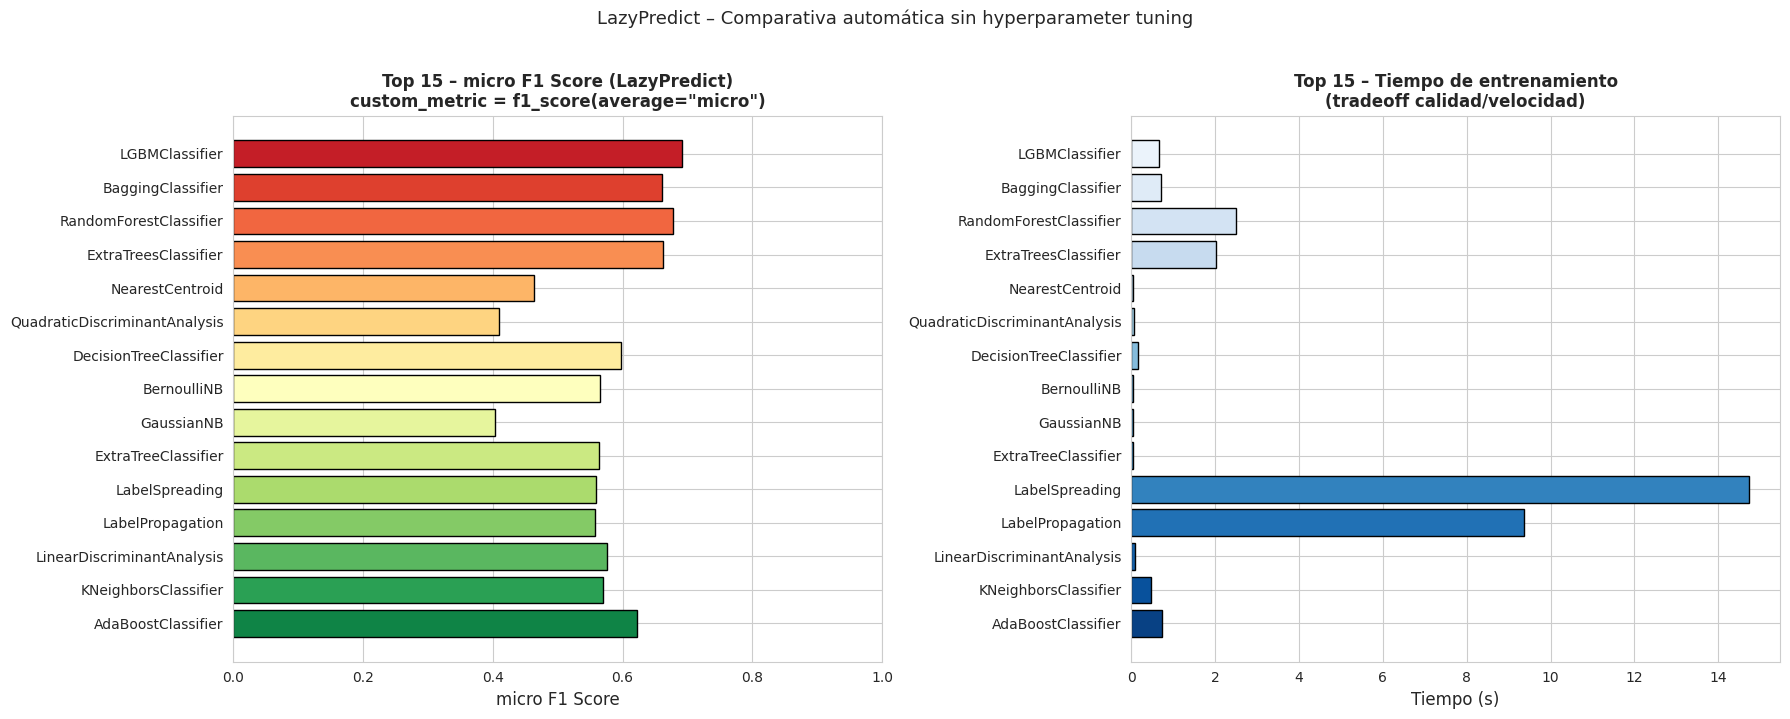

Conclusión: Los modelos de árbol (ExtraTrees, RandomForest, GradientBoosting)
suelen encabezar el ranking → se procede con ellos + SVM con tuning.


In [ ]:
# Métrica personalizada alineada con la competición
# Ref: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html
# micro averaged F1 – métrica oficial de DrivenData Nepal Earthquake.
# Calcula TP, FP, FN globalmente (sumando todas las clases) antes de calcular F1.
def micro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='micro')

print('Ejecutando LazyPredict con custom_metric=micro_f1... (2-5 min)')
lazy = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=micro_f1   # alineado con DrivenData
)
lazy_models, lazy_preds = lazy.fit(X_train, X_val, y_train, y_val)

print('\n' + '='*65)
print('LAZY PREDICT – Ranking de clasificadores (micro F1 personalizado)')
print('Ref: https://pypi.org/project/lazypredict/')
print('='*65)
print(lazy_models.to_string())

top_lazy = lazy_models.head(15).reset_index()
metric_col = 'micro_f1' if 'micro_f1' in top_lazy.columns else 'F1 Score'

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(top_lazy['Model'][::-1], top_lazy[metric_col][::-1],
             color=sns.color_palette('RdYlGn', 15)[::-1], edgecolor='black')
axes[0].set_xlabel('micro F1 Score', fontsize=12)
axes[0].set_title('Top 15 – micro F1 Score (LazyPredict)\n'
                  'custom_metric = f1_score(average="micro")',
                  fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 1)

axes[1].barh(top_lazy['Model'][::-1], top_lazy['Time Taken'][::-1],
             color=sns.color_palette('Blues_r', 15), edgecolor='black')
axes[1].set_xlabel('Tiempo (s)', fontsize=12)
axes[1].set_title('Top 15 – Tiempo de entrenamiento\n(tradeoff calidad/velocidad)',
                  fontsize=12, fontweight='bold')

plt.suptitle('LazyPredict – Comparativa automática sin hyperparameter tuning',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('09_lazy_predict.png', dpi=150, bbox_inches='tight')
plt.show()

print('Conclusión: Los modelos de árbol (ExtraTrees, RandomForest, GradientBoosting)')
print('suelen encabezar el ranking → se procede con ellos + SVM con tuning.')


## 9. Tres Modelos de Árboles con Cross Validation

| Modelo | Tipo | Notas |
|---|---|---|
| **DecisionTreeClassifier** | Árbol simple | Baseline interpretable |
| **RandomForestClassifier** | Ensemble (bagging, 200 árboles) | Robusto, gestiona bien variables binarias y categóricas |
| **GradientBoostingClassifier** | Ensemble (boosting secuencial) | Alta precisión, corrige errores iterativamente |

Evaluación: **Stratified 5-Fold CV** + validación holdout.  
Métrica en todos los casos: `f1_score(average='micro')` — igual que el leaderboard.


───────────────────────────────────────────────────────
  Decision Tree
───────────────────────────────────────────────────────
  micro F1 Train      : 0.6710
  micro F1 Validation : 0.5653
  CV micro F1 (5-fold): 0.5489 ± 0.0076

───────────────────────────────────────────────────────
  Random Forest
───────────────────────────────────────────────────────
  micro F1 Train      : 0.8059
  micro F1 Validation : 0.6484
  CV micro F1 (5-fold): 0.6364 ± 0.0059

───────────────────────────────────────────────────────
  Gradient Boosting
───────────────────────────────────────────────────────
  micro F1 Train      : 0.7696
  micro F1 Validation : 0.6963
  CV micro F1 (5-fold): 0.6803 ± 0.0068


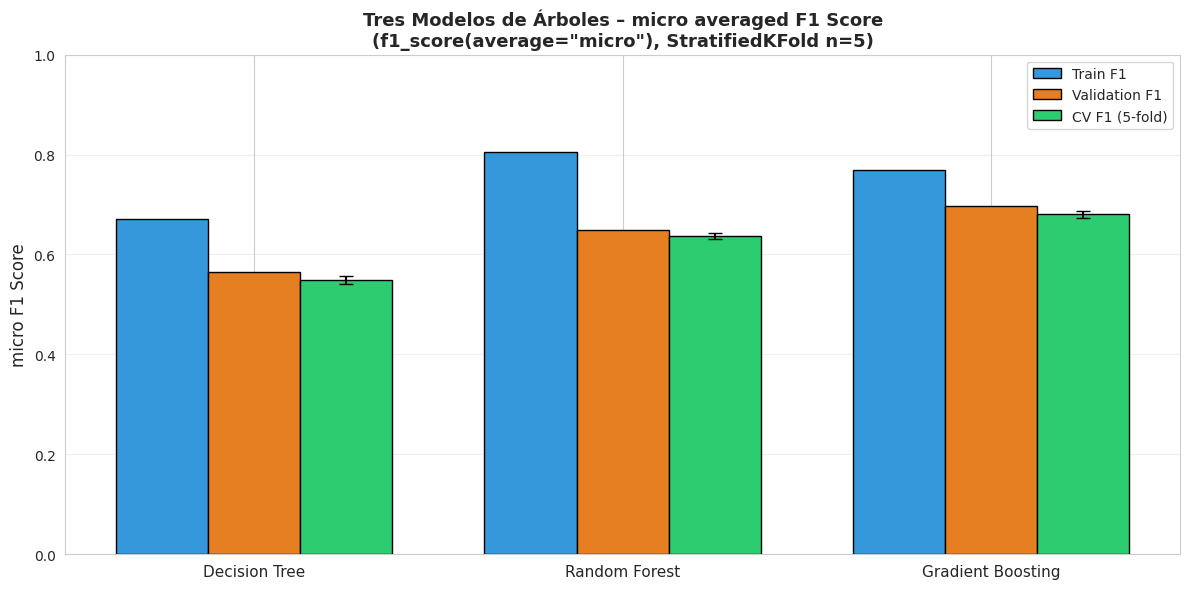

Mejor árbol: Gradient Boosting  (CV = 0.6803)


In [ ]:
# Función de evaluación centralizada
# Usa: f1_score(y_true, y_pred, average='micro')
# Ref: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html

results = {}

def eval_model(name, model, Xtr, ytr, Xv, yv, cv_obj):
    model.fit(Xtr, ytr)
    cv_s = cross_val_score(model, Xtr, ytr, cv=cv_obj, scoring='f1_micro', n_jobs=-1)
    f1_tr = f1_score(ytr, model.predict(Xtr), average='micro')
    f1_v  = f1_score(yv,  model.predict(Xv),  average='micro')
    print(f'\n{"─"*55}\n  {name}\n{"─"*55}')
    print(f'  micro F1 Train      : {f1_tr:.4f}')
    print(f'  micro F1 Validation : {f1_v:.4f}')
    print(f'  CV micro F1 (5-fold): {cv_s.mean():.4f} ± {cv_s.std():.4f}')
    results[name] = {'model': model, 'f1_train': f1_tr, 'f1_val': f1_v,
                     'cv_mean': cv_s.mean(), 'cv_std': cv_s.std()}
    return results[name]

# MODELO 1: Decision Tree
dt = DecisionTreeClassifier(max_depth=15, min_samples_split=20,
                             min_samples_leaf=10, class_weight='balanced', random_state=42)
eval_model('Decision Tree', dt, X_train, y_train, X_val, y_val, cv)

# MODELO 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=20, min_samples_leaf=5,
                             class_weight='balanced_subsample', random_state=42, n_jobs=-1)
eval_model('Random Forest', rf, X_train, y_train, X_val, y_val, cv)

# MODELO 3: Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                 max_depth=5, subsample=0.8, random_state=42)
eval_model('Gradient Boosting', gb, X_train, y_train, X_val, y_val, cv)

# Comparativa visual de los 3 árboles
tree_names = ['Decision Tree', 'Random Forest', 'Gradient Boosting']
x = np.arange(len(tree_names)); w = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - w, [results[n]['f1_train'] for n in tree_names], w, label='Train F1',      color='#3498db', edgecolor='black')
ax.bar(x,     [results[n]['f1_val']   for n in tree_names], w, label='Validation F1', color='#e67e22', edgecolor='black')
ax.bar(x + w, [results[n]['cv_mean']  for n in tree_names], w, label='CV F1 (5-fold)', color='#2ecc71', edgecolor='black',
       yerr=[results[n]['cv_std'] for n in tree_names], capsize=5)
ax.set_xticks(x); ax.set_xticklabels(tree_names, fontsize=11)
ax.set_ylabel('micro F1 Score', fontsize=12)
ax.set_title('Tres Modelos de Árboles – micro averaged F1 Score\n'
             '(f1_score(average="micro"), StratifiedKFold n=5)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.set_ylim(0, 1); ax.yaxis.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('10_comparativa_arboles.png', dpi=150, bbox_inches='tight')
plt.show()

best_tree = max(tree_names, key=lambda n: results[n]['cv_mean'])
print(f'Mejor árbol: {best_tree}  (CV = {results[best_tree]["cv_mean"]:.4f})')


## 10. Modelo SVM con GridSearch y RandomSearch

**SVC** con kernel RBF. El ajuste de C y gamma es fundamental para el rendimiento.

| Técnica | Espacio | Ventaja |
|---|---|---|
| **GridSearchCV** | Grilla fija y reducida | Garantiza el óptimo dentro del espacio definido |
| **RandomizedSearchCV** | Distribuciones continuas (loguniform) | Explora espacios mayores, más eficiente |

En ambos casos `scoring='f1_micro'` → misma métrica que el leaderboard de DrivenData.

In [ ]:
print('Entrenando SVM base (sin tuning)...')
eval_model('SVM Base', SVC(kernel='rbf', C=1.0, gamma='scale',
                           decision_function_shape='ovr', random_state=42),
           X_train, y_train, X_val, y_val, cv)

# ── GridSearchCV ────────────────────────────────────────────────────────────
print('\nGridSearchCV para SVM...')
grid_svm = GridSearchCV(
    SVC(decision_function_shape='ovr', random_state=42),
    {'C': [1, 10], 'gamma': ['scale'], 'kernel': ['rbf']},
    cv=cv, scoring='f1_micro', n_jobs=-1, verbose=1
)
grid_svm.fit(X_train, y_train)
print(f'GridSearch → mejores params: {grid_svm.best_params_}  CV F1={grid_svm.best_score_:.4f}')
eval_model('SVM (GridSearch)', grid_svm.best_estimator_, X_train, y_train, X_val, y_val, cv)

# ── RandomizedSearchCV ──────────────────────────────────────────────────────
# Explora espacios continuos (loguniform) → más eficiente que GridSearch
# Ref: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html
print('\nRandomizedSearchCV para SVM...')
rand_svm = RandomizedSearchCV(
    SVC(kernel='rbf', decision_function_shape='ovr', random_state=42),
    param_distributions={
        'C':     loguniform(0.1, 100),
        'gamma': loguniform(1e-4, 1e-1)
    },
    n_iter=10, cv=cv, scoring='f1_micro',
    n_jobs=-1, random_state=42, verbose=1
)
rand_svm.fit(X_train, y_train)
print(f'RandomSearch → mejores params: {rand_svm.best_params_}  CV F1={rand_svm.best_score_:.4f}')
eval_model('SVM (RandomSearch)', rand_svm.best_estimator_, X_train, y_train, X_val, y_val, cv)


Entrenando SVM base (sin tuning)...

───────────────────────────────────────────────────────
  SVM Base
───────────────────────────────────────────────────────
  micro F1 Train      : 0.6577
  micro F1 Validation : 0.6091
  CV micro F1 (5-fold): 0.6037 ± 0.0031

GridSearchCV para SVM...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
GridSearch → mejores params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}  CV F1=0.6037

───────────────────────────────────────────────────────
  SVM (GridSearch)
───────────────────────────────────────────────────────
  micro F1 Train      : 0.6577
  micro F1 Validation : 0.6091
  CV micro F1 (5-fold): 0.6037 ± 0.0031

RandomizedSearchCV para SVM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
RandomSearch → mejores params: {'C': np.float64(1.3292918943162166), 'gamma': np.float64(0.07114476009343425)}  CV F1=0.6072

───────────────────────────────────────────────────────
  SVM (RandomSearch)
────────────────────────────────────

{'model': SVC(C=np.float64(1.3292918943162166), gamma=np.float64(0.07114476009343425),
     random_state=42),
 'f1_train': 0.717578125,
 'f1_val': 0.616875,
 'cv_mean': np.float64(0.6071877698842166),
 'cv_std': np.float64(0.0032877393768866022)}

## 11. Comparativa Final y Selección de Modelo

COMPARATIVA FINAL – micro averaged F1 Score
Métrica: f1_score(y_true, y_pred, average="micro")
Ref: scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score
            Modelo  F1_Train  F1_Val  CV_F1_mean  CV_F1_std
 Gradient Boosting    0.7696  0.6963      0.6803     0.0068
     Random Forest    0.8059  0.6484      0.6364     0.0059
SVM (RandomSearch)    0.7176  0.6169      0.6072     0.0033
          SVM Base    0.6577  0.6091      0.6037     0.0031
  SVM (GridSearch)    0.6577  0.6091      0.6037     0.0031
     Decision Tree    0.6710  0.5653      0.5489     0.0076

Modelo seleccionado: Gradient Boosting
CV micro F1: 0.6803 ± 0.0068


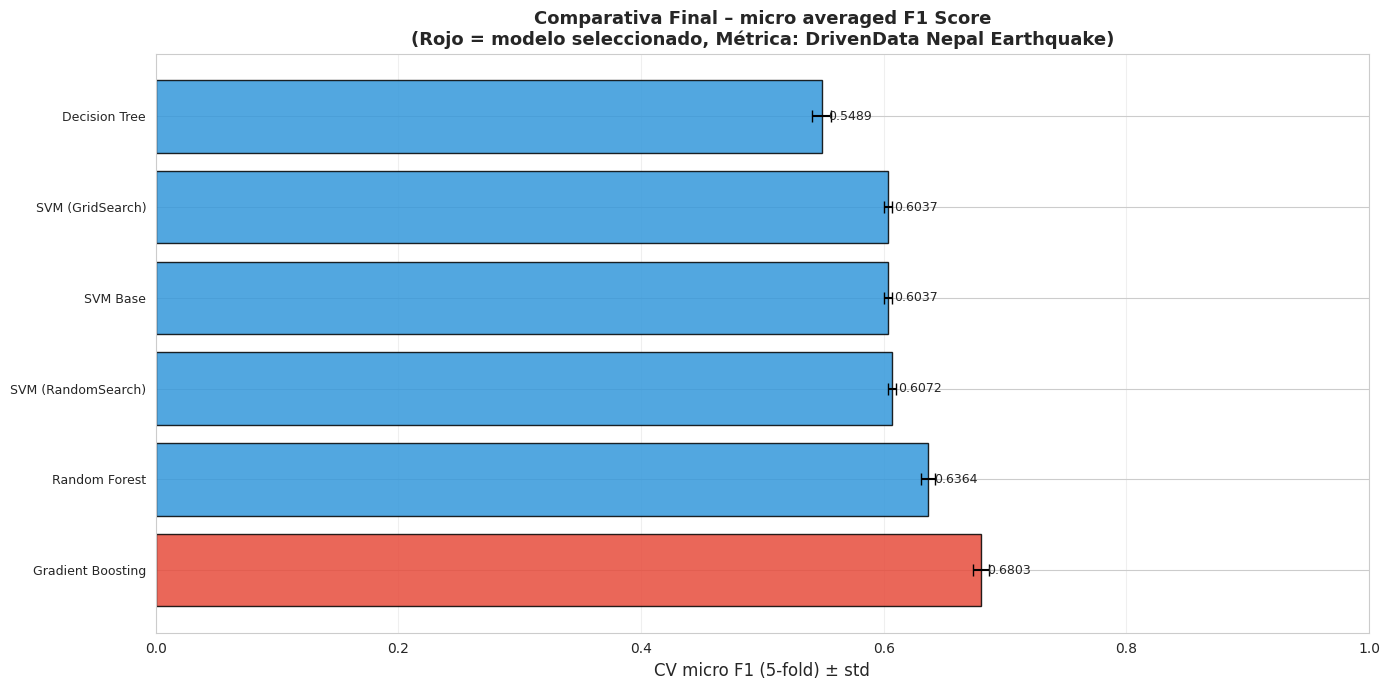

In [ ]:
summary = pd.DataFrame([
    {'Modelo': k, 'F1_Train': v['f1_train'], 'F1_Val': v['f1_val'],
     'CV_F1_mean': v['cv_mean'], 'CV_F1_std': v['cv_std']}
    for k, v in results.items()
]).sort_values('CV_F1_mean', ascending=False).reset_index(drop=True)

print('='*72)
print('COMPARATIVA FINAL – micro averaged F1 Score')
print('Métrica: f1_score(y_true, y_pred, average="micro")')
print('Ref: scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score')
print('='*72)
print(summary.to_string(index=False, float_format='{:.4f}'.format))

best_name  = summary.iloc[0]['Modelo']
best_model = results[best_name]['model']
print(f'\nModelo seleccionado: {best_name}')
print(f'CV micro F1: {summary.iloc[0]["CV_F1_mean"]:.4f} ± {summary.iloc[0]["CV_F1_std"]:.4f}')

fig, ax = plt.subplots(figsize=(14, 7))
y_pos = np.arange(len(summary))
c = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(summary))]
bars = ax.barh(y_pos, summary['CV_F1_mean'], xerr=summary['CV_F1_std'],
               color=c, edgecolor='black', capsize=4, alpha=0.85)
ax.set_yticks(y_pos); ax.set_yticklabels(summary['Modelo'], fontsize=9)
ax.set_xlabel('CV micro F1 (5-fold) ± std', fontsize=12)
ax.set_title('Comparativa Final – micro averaged F1 Score\n'
             '(Rojo = modelo seleccionado, Métrica: DrivenData Nepal Earthquake)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 1); ax.xaxis.grid(True, alpha=0.3)
for bar, val in zip(bars, summary['CV_F1_mean']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('11_comparativa_final.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Análisis Gráfico de Resultados

Reentrenando Gradient Boosting con train+val...
micro F1 Score (test interno): 0.6825

              precision    recall  f1-score   support

     Grado 1       0.63      0.37      0.46       385
     Grado 2       0.69      0.82      0.75      2276
     Grado 3       0.69      0.53      0.60      1339

    accuracy                           0.68      4000
   macro avg       0.67      0.57      0.60      4000
weighted avg       0.68      0.68      0.67      4000



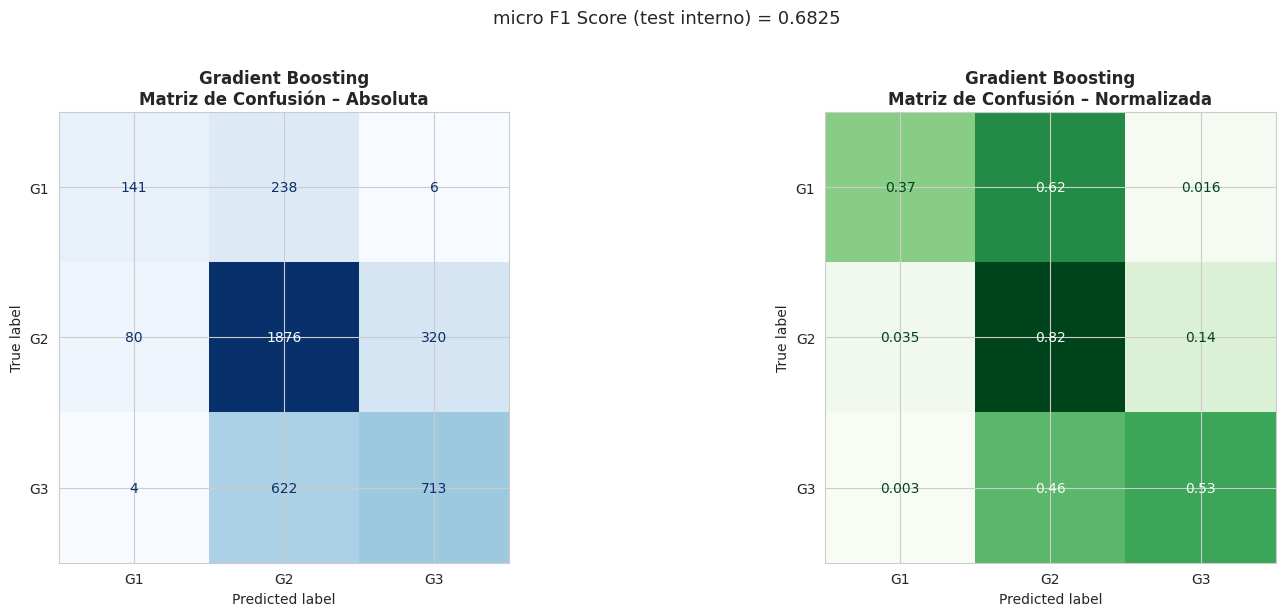

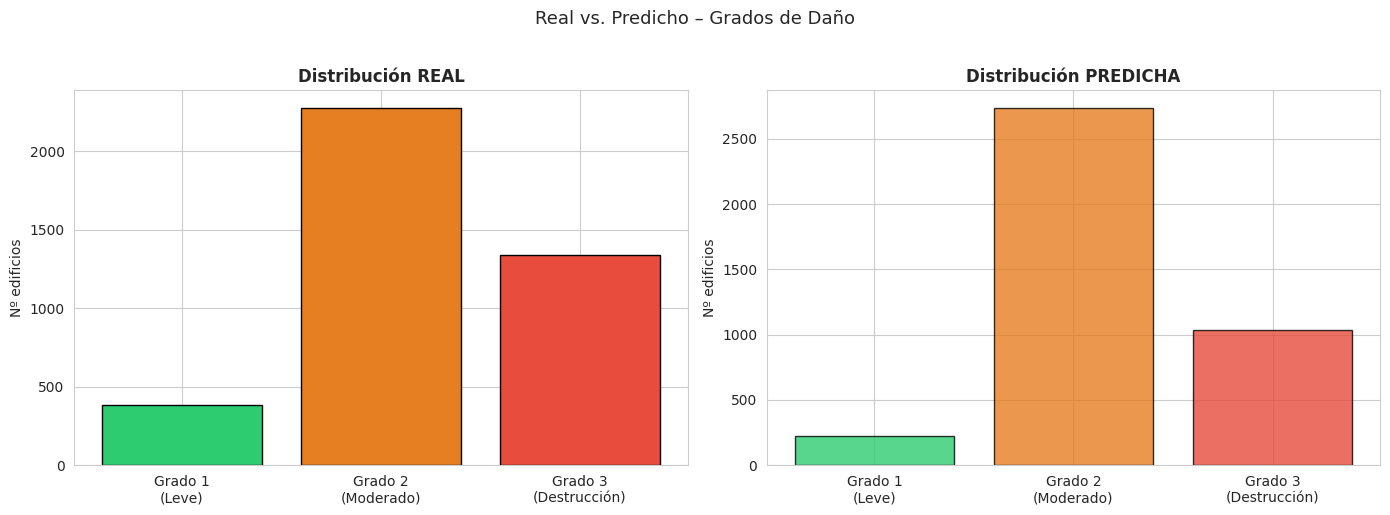

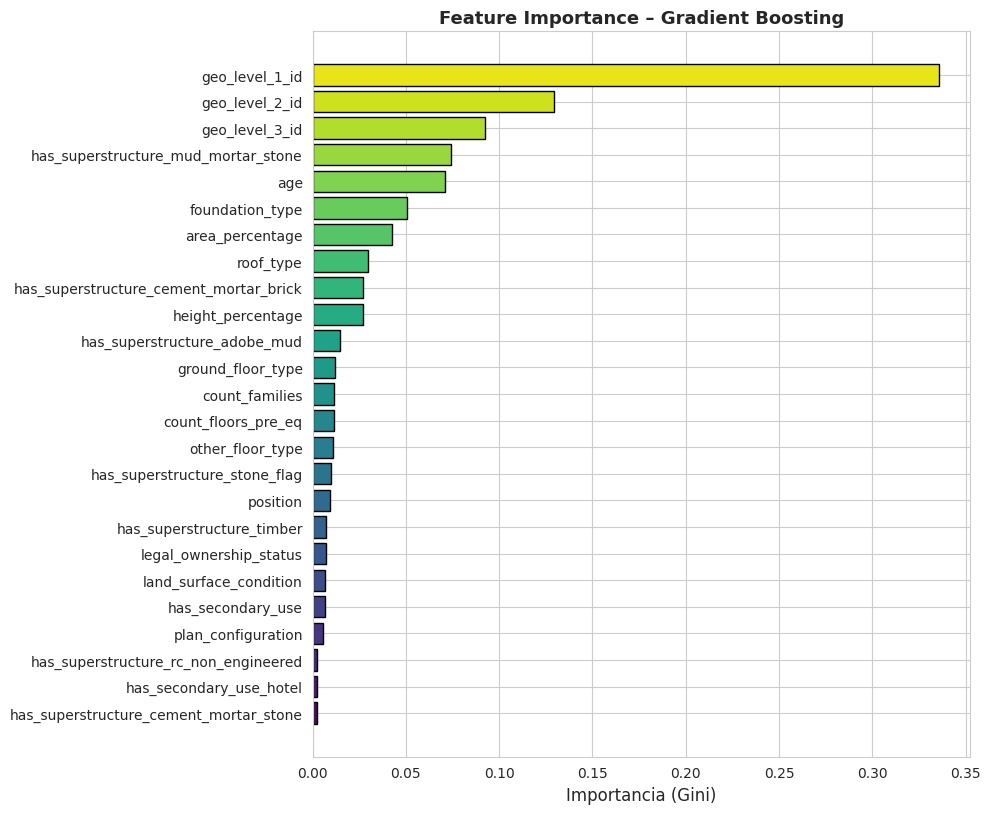

In [ ]:
print(f'Reentrenando {best_name} con train+val...')
best_model.fit(X_tr_full, y_tr_full)
y_pred_te = best_model.predict(X_te_int)
f1_te = f1_score(y_te_int, y_pred_te, average='micro')
print(f'micro F1 Score (test interno): {f1_te:.4f}')
print()
print(classification_report(y_te_int, y_pred_te, target_names=['Grado 1','Grado 2','Grado 3']))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm = confusion_matrix(y_te_int, y_pred_te)
ConfusionMatrixDisplay(cm, display_labels=['G1','G2','G3']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'{best_name}\nMatriz de Confusión – Absoluta', fontweight='bold')
ConfusionMatrixDisplay(confusion_matrix(y_te_int, y_pred_te, normalize='true'),
                       display_labels=['G1','G2','G3']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'{best_name}\nMatriz de Confusión – Normalizada', fontweight='bold')
plt.suptitle(f'micro F1 Score (test interno) = {f1_te:.4f}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('12_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels_g = ['Grado 1\n(Leve)', 'Grado 2\n(Moderado)', 'Grado 3\n(Destrucción)']
colors   = ['#2ecc71', '#e67e22', '#e74c3c']
rc = pd.Series(y_te_int).value_counts().sort_index()
pc = pd.Series(y_pred_te).value_counts().sort_index()
axes[0].bar(labels_g, rc.values, color=colors, edgecolor='black')
axes[0].set_title('Distribución REAL', fontweight='bold'); axes[0].set_ylabel('Nº edificios')
axes[1].bar(labels_g, pc.values, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_title('Distribución PREDICHA', fontweight='bold'); axes[1].set_ylabel('Nº edificios')
plt.suptitle('Real vs. Predicho – Grados de Daño', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('13_real_vs_predicho.png', dpi=150, bbox_inches='tight')
plt.show()

if hasattr(best_model, 'feature_importances_'):
    imp = pd.DataFrame({'Feature': final_features,
                        'Importance': best_model.feature_importances_}
                       ).sort_values('Importance', ascending=True)
    plt.figure(figsize=(10, max(6, len(imp)*0.33)))
    plt.barh(imp['Feature'], imp['Importance'],
             color=sns.color_palette('viridis', len(imp)), edgecolor='black')
    plt.xlabel('Importancia (Gini)', fontsize=12)
    plt.title(f'Feature Importance – {best_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('14_feat_importance_final.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('SVM no tiene feature_importances_ nativas; usar permutation_importance si se desea.')


## 13. Generación del Fichero de Submission

Formato exigido por DrivenData ([competitions/57/nepal-earthquake](https://www.drivendata.org/competitions/57/nepal-earthquake/data/)):

```
building_id,damage_grade
300051,3
99355,2
...
```

- Exactamente **86.868 filas**.
- `damage_grade` en {1, 2, 3}.
- Máximo **3 submissions diarios**.

In [ ]:
y_sub = best_model.predict(X_test_sel)

submission = pd.DataFrame({'building_id': test_values.index, 'damage_grade': y_sub})

assert submission['damage_grade'].isin([1, 2, 3]).all(), 'ERROR: valores fuera de [1,2,3]'
assert submission.isnull().sum().sum() == 0, 'ERROR: hay nulos'
assert len(submission) == len(test_values), 'ERROR: número de filas incorrecto'

fname = f'submission_{best_name.replace(" ","_").replace("(","").replace(")","")}.csv'
submission.to_csv(fname, index=False)

try:
    submission.to_csv(DRIVE_PATH + fname, index=False)
    print(f'Guardado en Drive: {DRIVE_PATH + fname}')
except Exception as e:
    print(f'No se pudo guardar en Drive: {e}')

print(f'Fichero listo: {fname}')
print(f'Subir en: https://www.drivendata.org/competitions/57/nepal-earthquake/submissions/')
print()
print('Distribución de predicciones:')
for v, c in zip(*np.unique(y_sub, return_counts=True)):
    print(f'  Grado {v}: {c:,} ({c/len(y_sub)*100:.1f}%)')
print()
print(submission.head(10).to_string(index=False))

from google.colab import files
files.download(fname)
print(f'Descargando {fname}...')


Guardado en Drive: /content/drive/MyDrive/Terremotos/submission_Gradient_Boosting.csv
Fichero listo: submission_Gradient_Boosting.csv
Subir en: https://www.drivendata.org/competitions/57/nepal-earthquake/submissions/

Distribución de predicciones:
  Grado 1: 5,154 (5.9%)
  Grado 2: 60,136 (69.2%)
  Grado 3: 21,578 (24.8%)

 building_id  damage_grade
      300051             3
       99355             2
      890251             2
      745817             1
      421793             3
      871976             2
      691228             2
      896100             3
      343471             2
      766647             2


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando submission_Gradient_Boosting.csv...
